In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset("mpg")

df.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [3]:
df = sns.load_dataset("mpg")

In [ ]:
# 1. Carga `auto_mpg.csv` y realiza el primer contacto con el dataset. 
# Reporta dimensiones, primeras fi las, tipos de datos y defi ne qué representa una fi la.

print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (398, 9)
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64 

In [5]:
# 2. Clasifi ca `mpg`, `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `model_year`, `origin` y `name`. 
# Identifi ca qué variables, aunque puedan verse numéricas, conviene tratar como categorías o variables temporales.

df_classified = df.copy()
df_classified['origin'] = df_classified['origin'].astype('category')
df_classified['cylinders'] = df_classified['cylinders'].astype('category')

In [6]:
# 3. Analiza valores faltantes y duplicados exactos. ¿En qué variable faltan datos y qué proporción representan?

print("Duplicados:", df.duplicated().sum())
print("Nulos en horsepower:", df['horsepower'].isnull().sum())
print("Proporción nulos HP:", f"{df['horsepower'].isnull().mean():.2%}")

Duplicados: 0
Nulos en horsepower: 6
Proporción nulos HP: 1.51%


In [7]:
# 4. Estudia la cardinalidad de `name`. ¿Cuántos nombres distintos hay? 
# ¿Que un nombre aparezca varias veces signifi ca que las fi las son duplicadas? Compruébalo con ejemplos.

print("Nombres únicos:", df['name'].nunique())

Nombres únicos: 305


In [8]:
# 5. Calcula estadísticos descriptivos de `mpg`, `weight` y `horsepower`: media, mediana, desviación estándar, cuartiles e IQR. 
# Interpreta qué te dicen sobre un automóvil “típico” y sobre la dispersión.

stats = df[['mpg', 'weight', 'horsepower']].describe().T
stats['IQR'] = stats['75%'] - stats['25%']
print(stats[['mean', '50%', 'std', '25%', '75%', 'IQR']])

                   mean     50%         std      25%     75%      IQR
mpg           23.514573    23.0    7.815984    17.50    29.0    11.50
weight      2970.424623  2803.5  846.841774  2223.75  3608.0  1384.25
horsepower   104.469388    93.5   38.491160    75.00   126.0    51.00


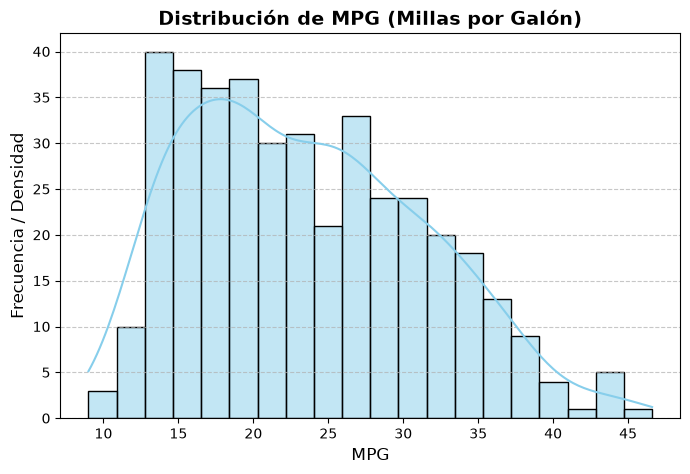

In [9]:
# 6. Analiza la distribución de `mpg` con histograma y KDE.

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='mpg', kde=True, bins=20, color='skyblue', edgecolor='black')

plt.title('Distribución de MPG (Millas por Galón)', fontsize=14, fontweight='bold')
plt.xlabel('MPG', fontsize=12)
plt.ylabel('Frecuencia / Densidad', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

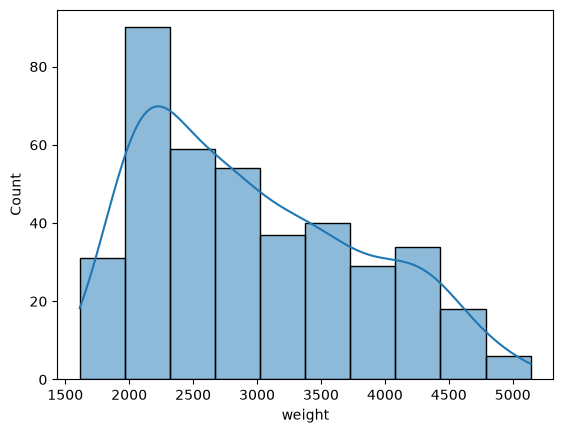

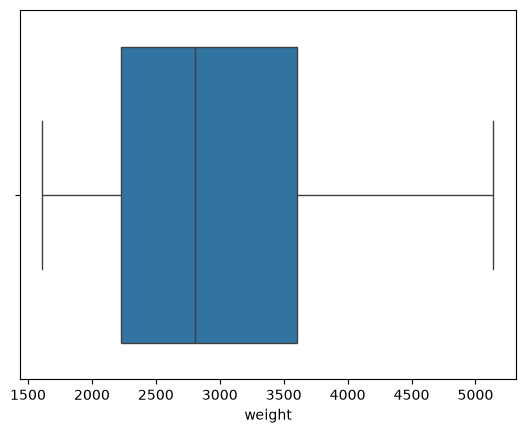

Q1: 2223.75
Q3: 3608.0
IQR: 1384.25
Límite inferior: 147.375
Límite superior: 5684.375


In [ ]:
# 7. Analiza `weight` con histograma y boxplot. ¿La distribución es simétrica? 
# ¿Hay valores extremos según la regla del IQR? Documenta el cálculo.

sns.histplot(df["weight"], kde=True)
plt.show()

sns.boxplot(x=df["weight"])
plt.show()

q1 = df["weight"].quantile(0.25)
q3 = df["weight"].quantile(0.75)
iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Límite inferior:", lim_inf)
print("Límite superior:", lim_sup)

In [12]:
# 8. Detecta outliers en `horsepower` usando 1.5·IQR. 
# Lista los vehículos identifi cados y comenta si parecen errores evidentes o automóviles de alta potencia plausibles.


q1 = df["horsepower"].quantile(0.25)
q3 = df["horsepower"].quantile(0.75)
iqr = q3 - q1

lim_sup = q3 + 1.5 * iqr

outliers = df[df["horsepower"] > lim_sup]

print("Límite superior:", lim_sup)
print(outliers[["name", "horsepower", "model_year"]])

Límite superior: 202.5
                             name  horsepower  model_year
6                chevrolet impala       220.0          70
7               plymouth fury iii       215.0          70
8                pontiac catalina       225.0          70
13        buick estate wagon (sw)       225.0          70
25                      ford f250       215.0          70
27                     dodge d200       210.0          70
67                mercury marquis       208.0          72
94   chrysler new yorker brougham       215.0          73
95       buick electra 225 custom       225.0          73
116            pontiac grand prix       230.0          73


Frecuencia de cilindros:
cylinders
4    204
8    103
6     84
3      4
5      3
Name: count, dtype: int64

Frecuencia de origen:
origin
usa       249
japan      79
europe     70
Name: count, dtype: int64


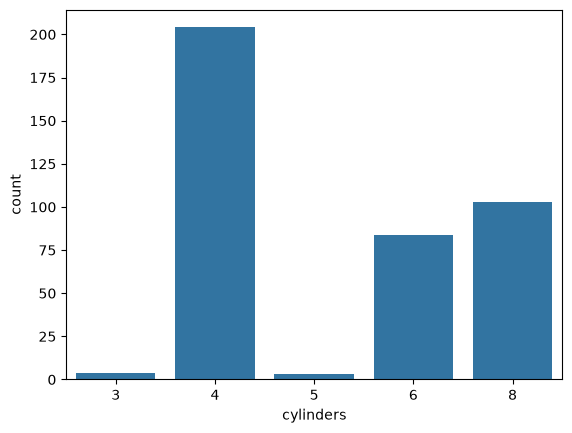

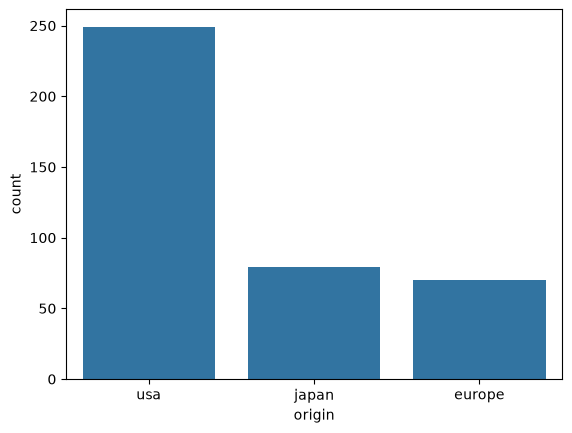

In [13]:
# 9. Explora `cylinders` y `origin` mediante frecuencias y gráfi cos de barras. 
# ¿Qué categorías dominan el dataset? ¿Hay categorías con muy pocos casos?

print("Frecuencia de cilindros:")
print(df["cylinders"].value_counts())

print("\nFrecuencia de origen:")
print(df["origin"].value_counts())

sns.countplot(x=df["cylinders"])
plt.show()

sns.countplot(x=df["origin"])
plt.show()


           count       mean  median
cylinders                          
3              4  20.550000   20.25
4            204  29.286765   28.25
5              3  27.366667   25.40
6             84  19.985714   19.00
8            103  14.963107   14.00


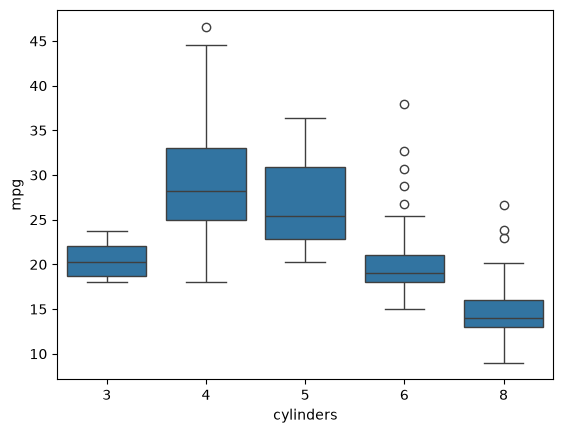

In [14]:
# 10. Compara `mpg` entre vehículos con distinto número de cilindros mediante boxplot y medias/medianas por grupo. ¿Qué patrón general observas?

print(df.groupby("cylinders")["mpg"].agg(["count", "mean", "median"]))

sns.boxplot(x="cylinders", y="mpg", data=df)
plt.show()

        count       mean  median       std
origin                                    
europe     70  27.891429    26.5  6.723930
japan      79  30.450633    31.6  6.090048
usa       249  20.083534    18.5  6.402892


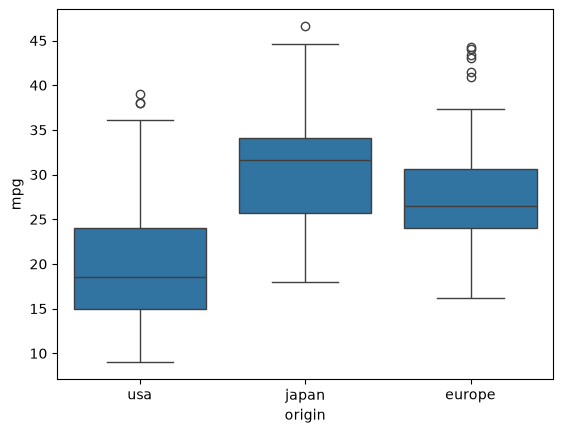

In [15]:
# 11. Compara `mpg` entre los tres orígenes del dataset. Usa boxplot y estadísticas por grupo.

print(df.groupby("origin")["mpg"].agg(["count", "mean", "median", "std"]))

sns.boxplot(x="origin", y="mpg", data=df)
plt.show()

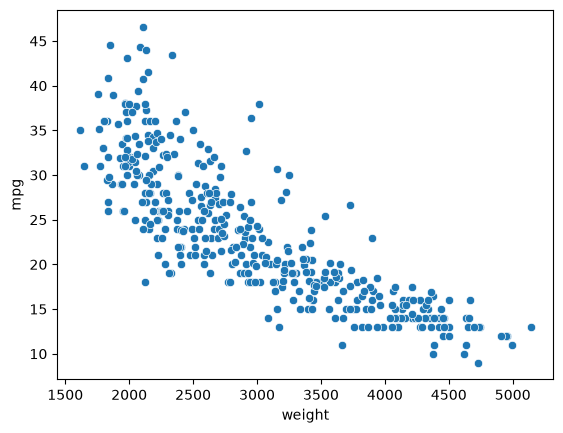

Correlación entre weight y mpg: -0.8317409332443354


In [16]:
# 12. Estudia la relación entre `weight` y `mpg` con un scatterplot y la correlación.

sns.scatterplot(x="weight", y="mpg", data=df)
plt.show()

correlacion = df["weight"].corr(df["mpg"])
print("Correlación entre weight y mpg:", correlacion)

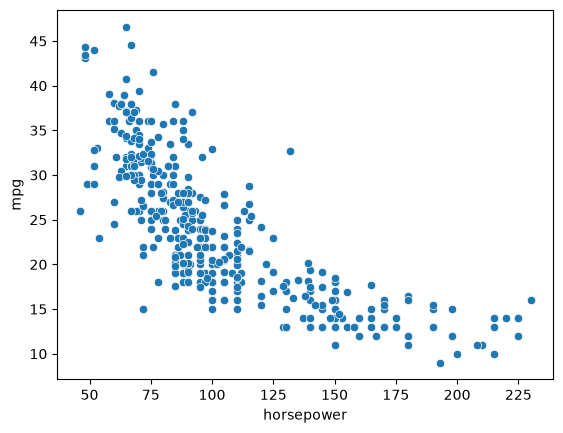

Correlación horsepower - mpg: -0.7784267838977761
Correlación weight - mpg: -0.8322442148315754


In [17]:
# 13. Estudia la relación entre `horsepower` y `mpg` con scatterplot y correlación. 
# Compara su intensidad con la relación `weight`–`mpg`.

df_clean = df.dropna(subset=["horsepower"])

sns.scatterplot(x="horsepower", y="mpg", data=df_clean)
plt.show()

corr_hp_mpg = df_clean["horsepower"].corr(df_clean["mpg"])
corr_weight_mpg = df_clean["weight"].corr(df_clean["mpg"])

print("Correlación horsepower - mpg:", corr_hp_mpg)
print("Correlación weight - mpg:", corr_weight_mpg)


Matriz de correlación:
                   mpg  displacement  horsepower    weight  acceleration
mpg           1.000000     -0.805127   -0.778427 -0.832244      0.423329
displacement -0.805127      1.000000    0.897257  0.932994     -0.543800
horsepower   -0.778427      0.897257    1.000000  0.864538     -0.689196
weight       -0.832244      0.932994    0.864538  1.000000     -0.416839
acceleration  0.423329     -0.543800   -0.689196 -0.416839      1.000000


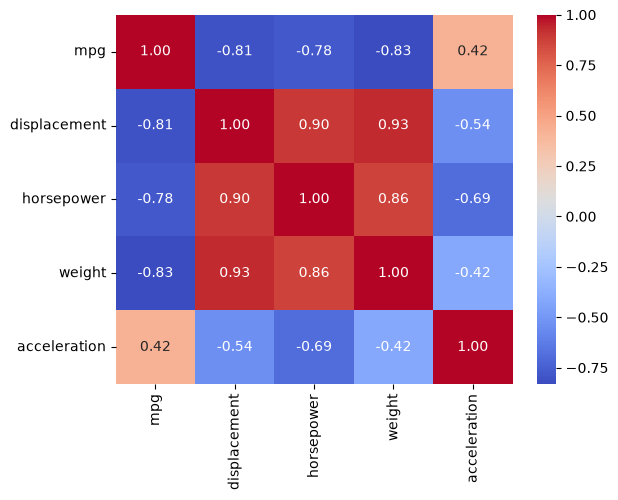

In [18]:
# 14. Construye una matriz de correlación y heatmap de las variables numéricas. 
# Identifi ca las tres variables con mayor asociación lineal absoluta con `mpg` y comenta posibles redundancias entre predictores.

num_cols = ["mpg", "displacement", "horsepower", "weight", "acceleration"]
df_num = df[num_cols].dropna()

matriz_corr = df_num.corr()
print("Matriz de correlación:")
print(matriz_corr)

sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

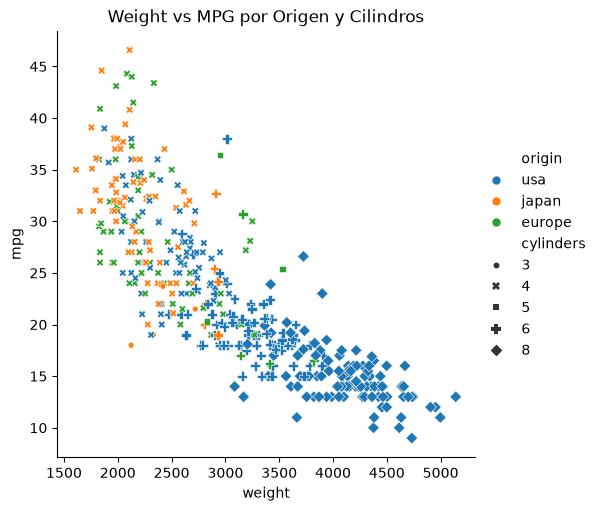

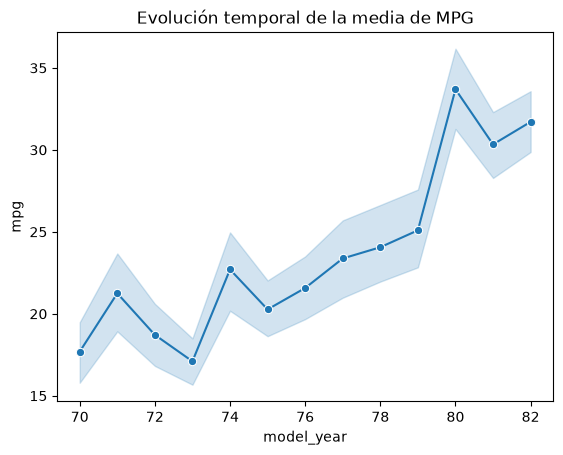

In [19]:
# 15. Realiza un análisis multivariado de `weight` frente a `mpg` incorporando `origin` y `cylinders` 
# (mediante color, estilo, facetas u otra codifi cación). Añade la evolución media de `mpg` por `model_year`.


sns.relplot(
    data=df, 
    x="weight", 
    y="mpg", 
    hue="origin", 
    style="cylinders", 
    size="cylinders"
)
plt.title("Weight vs MPG por Origen y Cilindros")
plt.show()

sns.lineplot(data=df, x="model_year", y="mpg", marker="o")
plt.title("Evolución temporal de la media de MPG")
plt.show()


Estadísticas de MPG por año:
                 mean  median
model_year                   
70          17.689655   16.00
71          21.250000   19.00
72          18.714286   18.50
73          17.100000   16.00
74          22.703704   24.00
75          20.266667   19.50
76          21.573529   21.00
77          23.375000   21.75
78          24.061111   20.70
79          25.093103   23.90
80          33.696552   32.70
81          30.334483   31.60
82          31.709677   32.00


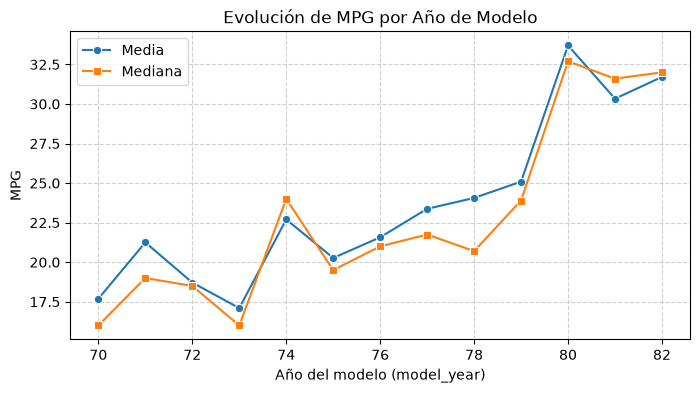

In [20]:
# 16. Analiza la evolución de `mpg` por `model_year`. Calcula media y mediana por año y represéntalas en una gráfi ca de líneas.

stats_year = df.groupby("model_year")["mpg"].agg(["mean", "median"])
print("Estadísticas de MPG por año:")
print(stats_year)

plt.figure(figsize=(8, 4))
sns.lineplot(data=stats_year, x="model_year", y="mean", label="Media", marker="o")
sns.lineplot(data=stats_year, x="model_year", y="median", label="Mediana", marker="s")
plt.title("Evolución de MPG por Año de Modelo")
plt.xlabel("Año del modelo (model_year)")
plt.ylabel("MPG")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

        count         mean  median         std
origin                                        
europe     70  2423.300000  2240.0  490.043191
japan      79  2221.227848  2155.0  320.497248
usa       249  3361.931727  3365.0  794.792506


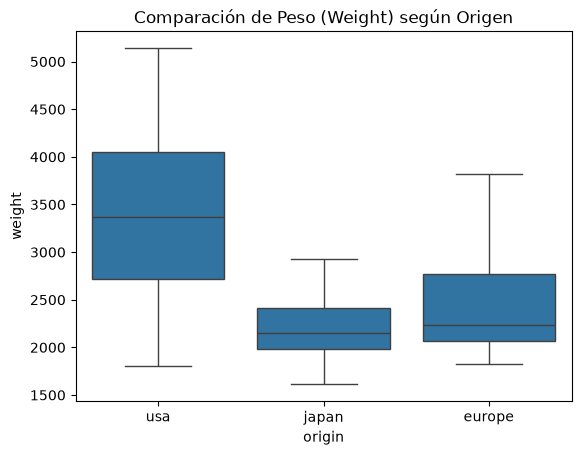

In [21]:
# 17. Compara el `weight` de los automóviles por `origin` mediante estadísticas y boxplots. 
# ¿Puede la diferencia de peso ayudar a explicar parte de las diferencias de `mpg` observadas entre orígenes?

print(df.groupby("origin")["weight"].agg(["count", "mean", "median", "std"]))

sns.boxplot(x="origin", y="weight", data=df)
plt.title("Comparación de Peso (Weight) según Origen")
plt.show()

In [22]:
# 18. Estudia el patrón de los valores faltantes de `horsepower`. Compara su frecuencia por `origin`, `cylinders` y `model_year`.

df["hp_isna"] = df["horsepower"].isna()

print("Filas con horsepower nulo:")
print(df[df["hp_isna"]][["name", "cylinders", "origin", "model_year"]])

print("\nNulos por origin:")
print(df.groupby("origin")["hp_isna"].sum())

print("\nNulos por cylinders:")
print(df.groupby("cylinders")["hp_isna"].sum())

print("\nNulos por model_year:")
print(df.groupby("model_year")["hp_isna"].sum())

Filas con horsepower nulo:
                     name  cylinders  origin  model_year
32             ford pinto          4     usa          71
126         ford maverick          6     usa          74
330  renault lecar deluxe          4  europe          80
336    ford mustang cobra          4     usa          80
354           renault 18i          4  europe          81
374        amc concord dl          4     usa          82

Nulos por origin:
origin
europe    2
japan     0
usa       4
Name: hp_isna, dtype: int64

Nulos por cylinders:
cylinders
3    0
4    5
5    0
6    1
8    0
Name: hp_isna, dtype: int64

Nulos por model_year:
model_year
70    0
71    1
72    0
73    0
74    1
75    0
76    0
77    0
78    0
79    0
80    2
81    1
82    1
Name: hp_isna, dtype: int64


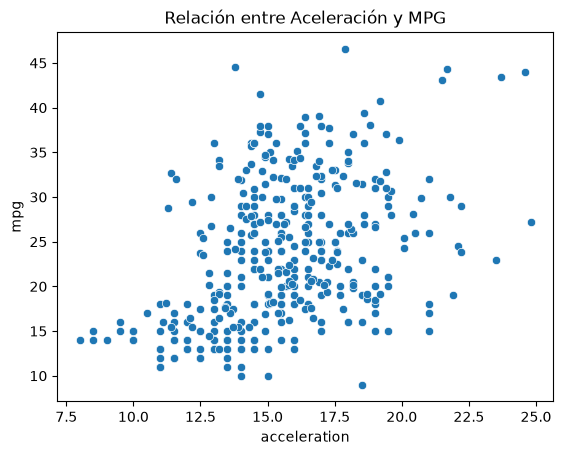

Correlación acceleration vs mpg: 0.4233285369027872
Correlación horsepower vs mpg:   -0.7784267838977761
Correlación weight vs mpg:       -0.8322442148315754


In [23]:
# 19. Analiza la relación entre `acceleration` y `mpg` mediante scatterplot y correlación de Pearson. 
# Compara su fuerza con las relaciones de `weight` y `horsepower` con `mpg`.

df_clean = df.dropna(subset=["horsepower"])

sns.scatterplot(x="acceleration", y="mpg", data=df_clean)
plt.title("Relación entre Aceleración y MPG")
plt.show()

corr_acc_mpg = df_clean["acceleration"].corr(df_clean["mpg"])
corr_hp_mpg = df_clean["horsepower"].corr(df_clean["mpg"])
corr_weight_mpg = df_clean["weight"].corr(df_clean["mpg"])

print("Correlación acceleration vs mpg:", corr_acc_mpg)
print("Correlación horsepower vs mpg:  ", corr_hp_mpg)
print("Correlación weight vs mpg:      ", corr_weight_mpg)


Correlación Displacement vs Horsepower: 0.8972570018434692
Correlación Displacement vs Weight:     0.9329944040890106
Correlación Horsepower vs Weight:       0.8645377375741443


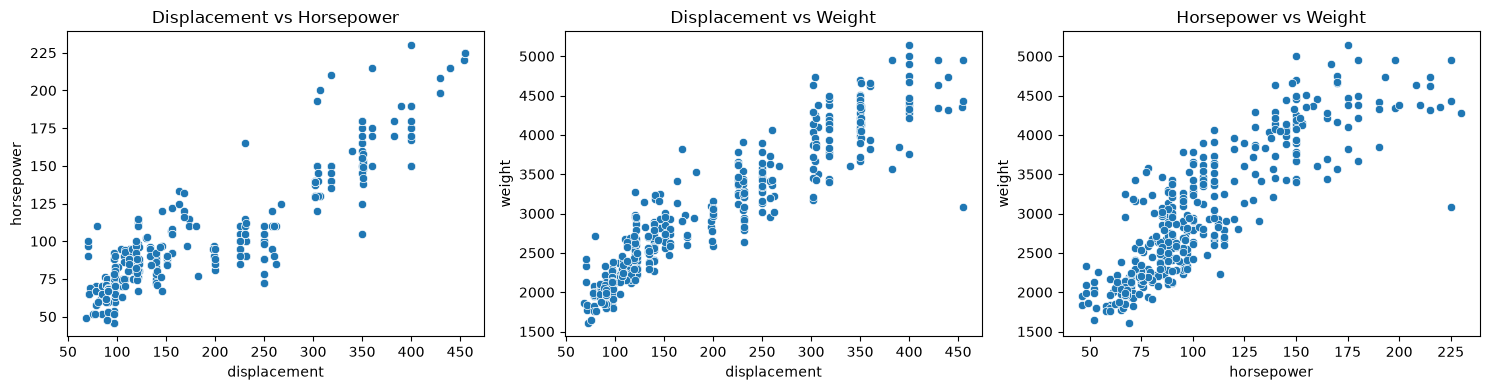

In [24]:
# 20. Explora las relaciones entre `displacement`, `horsepower` y `weight`. Calcula sus correlaciones y crea gráfi cos de dispersión. 
# ¿Qué problema podría aparecer si se usan simultáneamente como predictores sin revisar redundancias?

df_clean = df.dropna(subset=["horsepower"])

corr_disp_hp = df_clean["displacement"].corr(df_clean["horsepower"])
corr_disp_weight = df_clean["displacement"].corr(df_clean["weight"])
corr_hp_weight = df_clean["horsepower"].corr(df_clean["weight"])

print("Correlación Displacement vs Horsepower:", corr_disp_hp)
print("Correlación Displacement vs Weight:    ", corr_disp_weight)
print("Correlación Horsepower vs Weight:      ", corr_hp_weight)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(x="displacement", y="horsepower", data=df_clean, ax=axes[0])
axes[0].set_title("Displacement vs Horsepower")

sns.scatterplot(x="displacement", y="weight", data=df_clean, ax=axes[1])
axes[1].set_title("Displacement vs Weight")

sns.scatterplot(x="horsepower", y="weight", data=df_clean, ax=axes[2])
axes[2].set_title("Horsepower vs Weight")

plt.tight_layout()
plt.show()

In [25]:
# 21. Construye una tabla pivote con el `mpg` medio por `cylinders` y `origin`, incluyendo el número de automóviles por grupo. 
# ¿El patrón de cilindros se mantiene dentro de cada origen? Señala grupos con muestras pequeñas.

datos = {}

for i in range(len(df)):
    cyl = df["cylinders"].iloc[i]
    ori = df["origin"].iloc[i]
    mpg = df["mpg"].iloc[i]

    clave = (cyl, ori)

    # Si la pareja (cilindros, origen) no existe, creamos la lista
    if clave not in datos:
        datos[clave] = []

    # Agregamos el mpg a la lista
    datos[clave].append(mpg)

for clave, lista_mpg in sorted(datos.items()):
    cilindros = clave[0]
    origen = clave[1]
    cantidad = len(lista_mpg)
    promedio = sum(lista_mpg) / cantidad

    print("Cilindros:", cilindros, "| Origen:", origen, "| Cantidad:", cantidad, "| Promedio MPG:", round(promedio, 2))


Cilindros: 3 | Origen: japan | Cantidad: 4 | Promedio MPG: 20.55
Cilindros: 4 | Origen: europe | Cantidad: 63 | Promedio MPG: 28.41
Cilindros: 4 | Origen: japan | Cantidad: 69 | Promedio MPG: 31.6
Cilindros: 4 | Origen: usa | Cantidad: 72 | Promedio MPG: 27.84
Cilindros: 5 | Origen: europe | Cantidad: 3 | Promedio MPG: 27.37
Cilindros: 6 | Origen: europe | Cantidad: 4 | Promedio MPG: 20.1
Cilindros: 6 | Origen: japan | Cantidad: 6 | Promedio MPG: 23.88
Cilindros: 6 | Origen: usa | Cantidad: 74 | Promedio MPG: 19.66
Cilindros: 8 | Origen: usa | Cantidad: 103 | Promedio MPG: 14.96


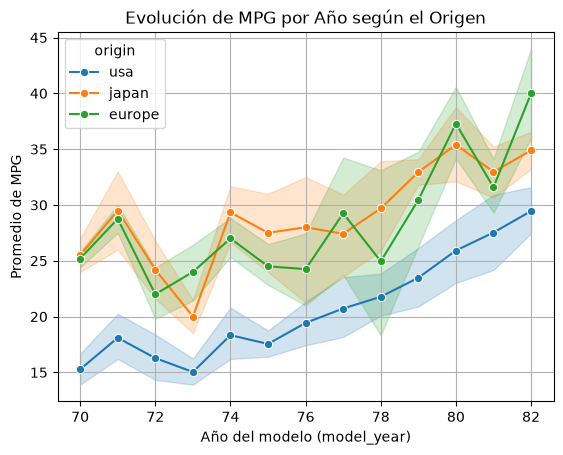

In [26]:
# 22. Compara la evolución temporal de `mpg` entre `origin` usando líneas por grupo. 
# ¿Los tres orígenes mejoran con el tiempo? ¿La brecha entre orígenes permanece constante?

sns.lineplot(data=df, x="model_year", y="mpg", hue="origin", marker="o")

plt.title("Evolución de MPG por Año según el Origen")
plt.xlabel("Año del modelo (model_year)")
plt.ylabel("Promedio de MPG")
plt.grid(True)
plt.show()

In [28]:
# 23. Compara los outliers de `horsepower` detectados mediante 1.5·IQR y mediante |z| > 3. 
# Lista los vehículos más extremos y explica por qué un método puede ser más estricto que el otro en una distribución asimétrica.

df_hp = df.dropna(subset=["horsepower"]).copy()

q1 = df_hp["horsepower"].quantile(0.25)
q3 = df_hp["horsepower"].quantile(0.75)
iqr = q3 - q1

limite_iqr = q3 + (1.5 * iqr)
outliers_iqr = df_hp[df_hp["horsepower"] > limite_iqr]

promedio = df_hp["horsepower"].mean()
desviacion = df_hp["horsepower"].std()

df_hp["z_score"] = (df_hp["horsepower"] - promedio) / desviacion
outliers_z = df_hp[df_hp["z_score"] > 3]

print("Autos raros segun IQR:", len(outliers_iqr))
print("Autos raros segun Z-score:", len(outliers_z))

print("\nLos autos mas extremos segun Z-score:")
print(outliers_z[["name", "horsepower", "z_score"]])

Autos raros segun IQR: 10
Autos raros segun Z-score: 5

Los autos mas extremos segun Z-score:
                         name  horsepower   z_score
6            chevrolet impala       220.0  3.001484
8            pontiac catalina       225.0  3.131384
13    buick estate wagon (sw)       225.0  3.131384
95   buick electra 225 custom       225.0  3.131384
116        pontiac grand prix       230.0  3.261284


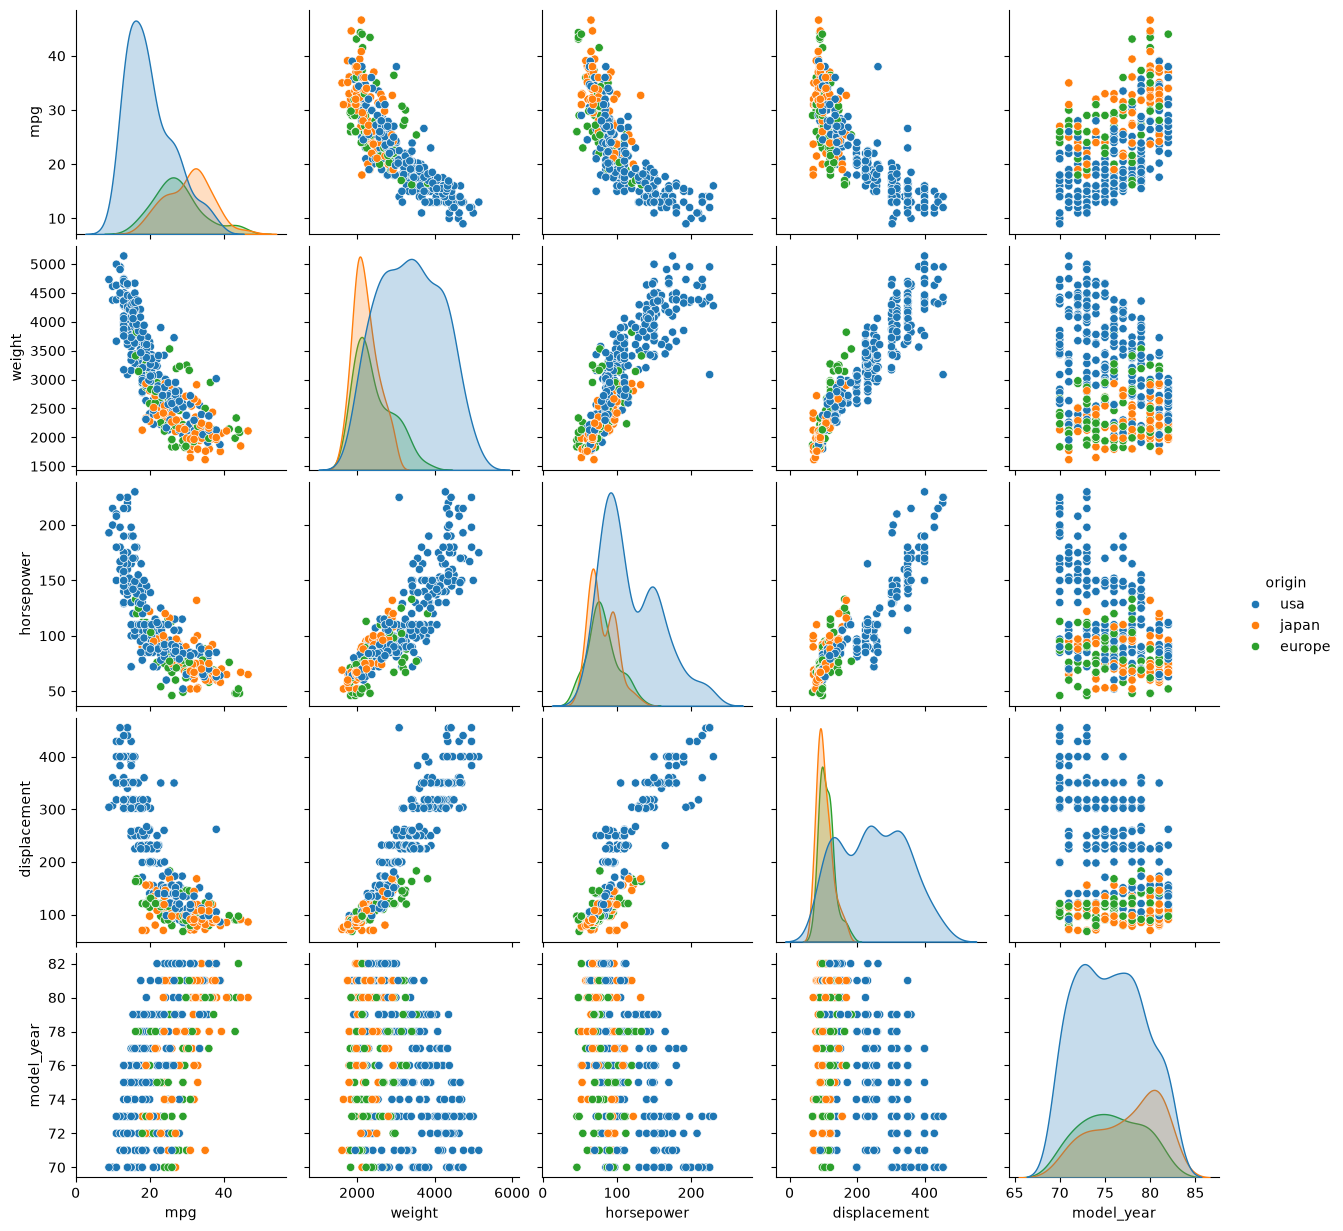

In [29]:
# 24. Construye un `pairplot` con `mpg`, `weight`, `horsepower`, `displacement` y `model_year`, usando `origin` como color.

cols = ["mpg", "weight", "horsepower", "displacement", "model_year", "origin"]
df_pair = df[cols].dropna()

sns.pairplot(df_pair, hue="origin")
plt.show()

In [30]:
# 25. Elabora un “registro de decisiones” para preparar un análisis posterior: decide qué harías con los nulos de `horsepower`, 
# `name`, `origin`, los outliers de potencia y las variables altamente correlacionadas.

decisiones = [
    ("Nulos en horsepower", 
     "En EDA: Dejar los datos y solo borrar los nulos cuando se use horsepower.", 
     "En Modelado: Borrar las 6 filas o rellenar con la mediana de sus cilindros."),
    
    ("Variable name", 
     "En EDA: Sirve para ver qué autos son los más potentes o raros.", 
     "En Modelado: Eliminar la columna porque tiene demasiados nombres distintos."),
    
    ("Variable origin", 
     "En EDA: Usar tal cual para comparar EE.UU., Europa y Japón.", 
     "En Modelado: Convertir a números (0 y 1) para que el modelo la entienda."),
    
    ("Autos potentes (Outliers)", 
     "En EDA: Guardarlos para entender cómo eran los autos grandes de los 70.", 
     "En Modelado: Mantenerlos pero aplicar un cambio de escala (como logaritmo)."),
    
    ("Variables repetidas (peso, potencia, motor)", 
     "En EDA: Analizar las tres para ver cómo se relacionan.", 
     "En Modelado: Quedarnos solo con weight (peso) y quitar las demás.")
]

# 2. Imprimimos el registro de decisiones
for aspecto, eda, modelado in decisiones:
    print("PUNTO:", aspecto)
    print(" -", eda)
    print(" -", modelado)
    print("-" * 40)


PUNTO: Nulos en horsepower
 - En EDA: Dejar los datos y solo borrar los nulos cuando se use horsepower.
 - En Modelado: Borrar las 6 filas o rellenar con la mediana de sus cilindros.
----------------------------------------
PUNTO: Variable name
 - En EDA: Sirve para ver qué autos son los más potentes o raros.
 - En Modelado: Eliminar la columna porque tiene demasiados nombres distintos.
----------------------------------------
PUNTO: Variable origin
 - En EDA: Usar tal cual para comparar EE.UU., Europa y Japón.
 - En Modelado: Convertir a números (0 y 1) para que el modelo la entienda.
----------------------------------------
PUNTO: Autos potentes (Outliers)
 - En EDA: Guardarlos para entender cómo eran los autos grandes de los 70.
 - En Modelado: Mantenerlos pero aplicar un cambio de escala (como logaritmo).
----------------------------------------
PUNTO: Variables repetidas (peso, potencia, motor)
 - En EDA: Analizar las tres para ver cómo se relacionan.
 - En Modelado: Quedarnos sol